# AI-Powered Product Feature Prioritization System




##  #Importing Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import shap
import warnings
warnings.filterwarnings('ignore')




##  #Generating the Dataset

We simulate 500 product features with realistic metrics.
Each feature has attributes that a product manager would typically evaluate.


In [32]:
np.random.seed(42)
n_samples = 500

data = pd.DataFrame({
    'Feature_ID'         : range(1, n_samples + 1),
    'Customer_Demand'    : np.random.randint(40, 100, n_samples),   # How much customers want it (1-100)
    'Revenue_Impact'     : np.random.randint(10, 80,  n_samples),   # Expected revenue boost (%)
    'Development_Effort' : np.random.randint(1,  10,  n_samples),   # Engineering effort (1-10)
    'Churn_Reduction'    : np.random.randint(5,  50,  n_samples),   # Expected churn drop (%)
    'Engagement_Score'   : np.random.randint(30, 100, n_samples),   # User engagement impact (1-100)
    'Strategic_Value'    : np.random.randint(1,  10,  n_samples),   # Business strategy alignment (1-10)
    'Bug_Risk'           : np.random.randint(1,  10,  n_samples),   # Risk of introducing bugs (1-10)
    'Time_To_Implement'  : np.random.randint(1,  20,  n_samples),   # Weeks to build
})

print("Dataset created:", data.shape)
data.head()


Dataset created: (500, 9)


,Feature_ID,Customer_Demand,Revenue_Impact,Development_Effort,Churn_Reduction,Engagement_Score,Strategic_Value,Bug_Risk,Time_To_Implement
0,1,78,16,8,46,55,6,5,18
1,2,91,66,9,40,54,5,6,12
2,3,68,45,5,31,41,4,2,9
3,4,54,54,3,42,34,3,4,5
4,5,82,29,5,11,77,4,3,10


## 3. Feature Engineering

We create new meaningful columns from the raw data.
These are industry-standard PM scoring formulas.


In [33]:
# ROI Score — revenue earned per unit of effort
data['ROI_Score'] = (data['Revenue_Impact'] / data['Development_Effort']).round(2)

# Release Risk — combined risk of shipping this feature
data['Release_Risk'] = data['Bug_Risk'] + data['Development_Effort'] + data['Time_To_Implement']

# Adoption Score — weighted customer + engagement signal
data['Adoption_Score'] = (data['Customer_Demand'] * 0.6 + data['Engagement_Score'] * 0.4).round(2)

# RICE Score — standard PM prioritisation framework (Reach × Impact × Confidence / Effort)
data['RICE_Score'] = (
    data['Customer_Demand'] * data['Revenue_Impact'] * data['Strategic_Value']
) / data['Development_Effort']

# Business Value — weighted mix of revenue, retention, and engagement
data['Business_Value'] = (
    data['Revenue_Impact'] * 0.4 +
    data['Churn_Reduction'] * 0.3 +
    data['Engagement_Score'] * 0.3
).round(2)

print("Feature engineering done")
data.head()


Feature engineering done


,Feature_ID,Customer_Demand,Revenue_Impact,Development_Effort,Churn_Reduction,Engagement_Score,Strategic_Value,Bug_Risk,Time_To_Implement,ROI_Score,Release_Risk,Adoption_Score,RICE_Score,Business_Value
0,1,78,16,8,46,55,6,5,18,2.00,31,68.8,936.000000,36.7
1,2,91,66,9,40,54,5,6,12,7.33,27,76.2,3336.666667,54.6
2,3,68,45,5,31,41,4,2,9,9.00,16,57.2,2448.000000,39.6
3,4,54,54,3,42,34,3,4,5,18.00,12,46.0,2916.000000,44.4
4,5,82,29,5,11,77,4,3,10,5.80,18,80.0,1902.400000,38.0


##  #Adding Extra Columns


In [34]:
# ── MoSCoW Label (rule-based, easy to explain in interviews) ──────────
def assign_moscow(row):
    if row['Customer_Demand'] >= 80 and row['Revenue_Impact'] >= 50:
        return 'Must Have'
    elif row['Customer_Demand'] >= 60 or row['Revenue_Impact'] >= 40:
        return 'Should Have'
    elif row['Strategic_Value'] >= 6:
        return 'Could Have'
    else:
        return "Won't Have"

data['MoSCoW_Label'] = data.apply(assign_moscow, axis=1)

#Feature Category (business segmentation for Power BI)
categories = ['Growth', 'Retention', 'Monetization', 'Infrastructure', 'UX Improvement']
data['Feature_Category'] = np.random.choice(categories, n_samples, p=[0.25, 0.20, 0.20, 0.15, 0.20])

# Effort-Value Ratio (used in model — genuine signal)
data['Effort_Value_Ratio'] = (data['Development_Effort'] / data['Business_Value']).round(4)

print("New columns added")
print("\nMoSCoW distribution:")
print(data['MoSCoW_Label'].value_counts())
print("\nFeature Category distribution:")
print(data['Feature_Category'].value_counts())
data.head()


New columns added

MoSCoW distribution:
MoSCoW_Label
Should Have    358
Must Have       70
Won't Have      43
Could Have      29
Name: count, dtype: int64

Feature Category distribution:
Feature_Category
Monetization      110
Growth            107
UX Improvement    101
Retention          97
Infrastructure     85
Name: count, dtype: int64


,Feature_ID,Customer_Demand,Revenue_Impact,Development_Effort,Churn_Reduction,Engagement_Score,Strategic_Value,Bug_Risk,Time_To_Implement,ROI_Score,Release_Risk,Adoption_Score,RICE_Score,Business_Value,MoSCoW_Label,Feature_Category,Effort_Value_Ratio
0,1,78,16,8,46,55,6,5,18,2.00,31,68.8,936.000000,36.7,Should Have,Retention,0.2180
1,2,91,66,9,40,54,5,6,12,7.33,27,76.2,3336.666667,54.6,Must Have,Infrastructure,0.1648
2,3,68,45,5,31,41,4,2,9,9.00,16,57.2,2448.000000,39.6,Should Have,Growth,0.1263
3,4,54,54,3,42,34,3,4,5,18.00,12,46.0,2916.000000,44.4,Should Have,Retention,0.0676
4,5,82,29,5,11,77,4,3,10,5.80,18,80.0,1902.400000,38.0,Should Have,Monetization,0.1316


## #Creating the Priority Label (Target Variable)



In [35]:
priority_score = (
    data['Customer_Demand']    * 0.20 +
    data['Revenue_Impact']     * 0.15 +
    data['Churn_Reduction']    * 0.10 +
    data['Business_Value']     * 0.20 +
    data['ROI_Score']          * 0.15 +
    data['Adoption_Score']     * 0.10 +
    data['Strategic_Value']    * 5    +
    data['Release_Risk']       * -0.10 +
    data['Bug_Risk']           * -2   +
    np.random.normal(0, 5, len(data))   # small noise = real-world uncertainty
)

data['Priority'] = pd.qcut(priority_score, q=3, labels=['Low', 'Medium', 'High'])

print("Priority distribution (balanced using quantiles):")
print(data['Priority'].value_counts())
data.head()


Priority distribution (balanced using quantiles):
Priority
Low       167
High      167
Medium    166
Name: count, dtype: int64


,Feature_ID,Customer_Demand,Revenue_Impact,Development_Effort,Churn_Reduction,Engagement_Score,Strategic_Value,Bug_Risk,Time_To_Implement,ROI_Score,Release_Risk,Adoption_Score,RICE_Score,Business_Value,MoSCoW_Label,Feature_Category,Effort_Value_Ratio,Priority
0,1,78,16,8,46,55,6,5,18,2.00,31,68.8,936.000000,36.7,Should Have,Retention,0.2180,Medium
1,2,91,66,9,40,54,5,6,12,7.33,27,76.2,3336.666667,54.6,Must Have,Infrastructure,0.1648,High
2,3,68,45,5,31,41,4,2,9,9.00,16,57.2,2448.000000,39.6,Should Have,Growth,0.1263,Medium
3,4,54,54,3,42,34,3,4,5,18.00,12,46.0,2916.000000,44.4,Should Have,Retention,0.0676,Medium
4,5,82,29,5,11,77,4,3,10,5.80,18,80.0,1902.400000,38.0,Should Have,Monetization,0.1316,Medium


##  #Exploratory Data Analysis (EDA)

In [36]:
print("Dataset Shape:", data.shape)
print("\nData Types:")
print(data.dtypes)
print("\nMissing Values:")
print(data.isnull().sum())


Dataset Shape: (500, 18)

Data Types:
Feature_ID               int64
Customer_Demand          int64
Revenue_Impact           int64
Development_Effort       int64
Churn_Reduction          int64
Engagement_Score         int64
Strategic_Value          int64
Bug_Risk                 int64
Time_To_Implement        int64
ROI_Score              float64
Release_Risk             int64
Adoption_Score         float64
RICE_Score             float64
Business_Value         float64
MoSCoW_Label            object
Feature_Category        object
Effort_Value_Ratio     float64
Priority              category
dtype: object

Missing Values:
Feature_ID            0
Customer_Demand       0
Revenue_Impact        0
Development_Effort    0
Churn_Reduction       0
Engagement_Score      0
Strategic_Value       0
Bug_Risk              0
Time_To_Implement     0
ROI_Score             0
Release_Risk          0
Adoption_Score        0
RICE_Score            0
Business_Value        0
MoSCoW_Label          0
Feature_Categ

In [37]:
data.describe()


,Feature_ID,Customer_Demand,Revenue_Impact,Development_Effort,Churn_Reduction,Engagement_Score,Strategic_Value,Bug_Risk,Time_To_Implement,ROI_Score,Release_Risk,Adoption_Score,RICE_Score,Business_Value,Effort_Value_Ratio
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,70.396000,43.996000,5.046000,26.706000,61.714000,5.076000,4.930000,9.990000,13.897840,19.966000,66.923200,4795.498447,44.124400,0.120784
std,144.481833,17.335982,20.927396,2.640801,12.837959,19.923707,2.611487,2.578837,5.648869,14.865705,6.720951,12.928229,6272.995281,10.850025,0.070753
min,1.000000,40.000000,10.000000,1.000000,5.000000,30.000000,1.000000,1.000000,1.000000,1.250000,3.000000,36.800000,84.285714,18.100000,0.014200
25%,125.750000,56.750000,25.000000,3.000000,16.000000,45.000000,3.000000,3.000000,5.000000,5.200000,15.000000,57.200000,1197.000000,36.375000,0.064375
50%,250.500000,71.000000,43.000000,5.000000,26.500000,60.000000,5.000000,5.000000,10.000000,8.840000,20.000000,66.900000,2765.785714,43.800000,0.115450
75%,375.250000,85.000000,63.000000,7.000000,37.250000,78.250000,7.000000,7.000000,15.000000,15.397500,25.000000,75.600000,5209.500000,52.200000,0.165100
max,500.000000,99.000000,79.000000,9.000000,49.000000,99.000000,9.000000,9.000000,19.000000,78.000000,36.000000,97.800000,43148.000000,73.500000,0.373800


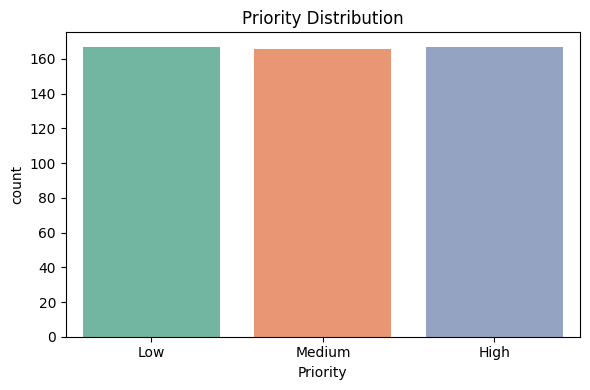

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Priority', data=data, palette='Set2')
plt.title('Priority Distribution')
plt.tight_layout()
plt.show()


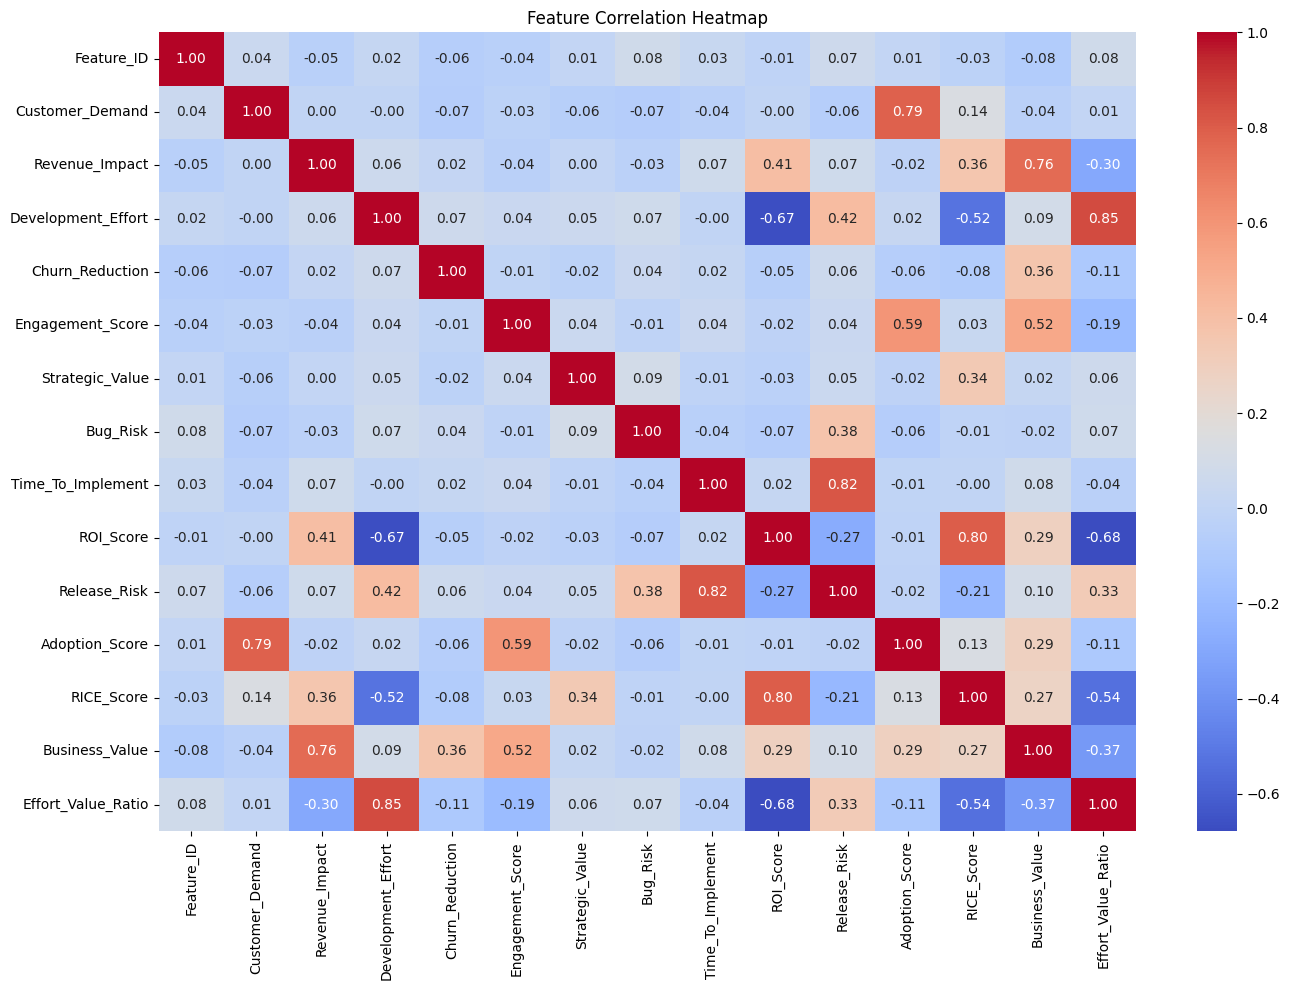

In [39]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


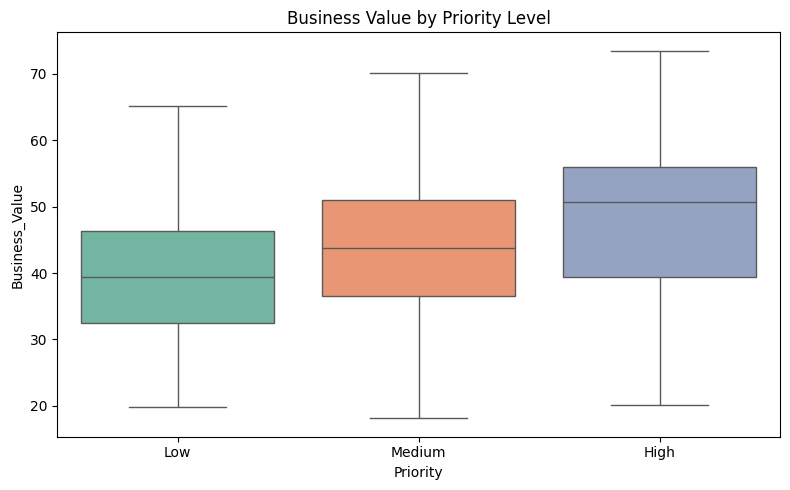

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Priority', y='Business_Value', data=data, palette='Set2')
plt.title('Business Value by Priority Level')
plt.tight_layout()
plt.show()


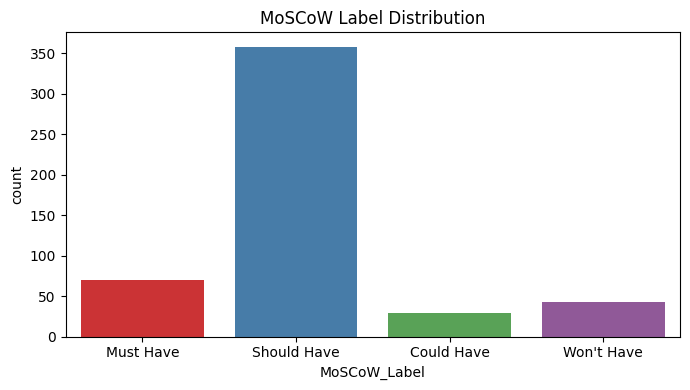

In [41]:
plt.figure(figsize=(7, 4))
sns.countplot(x='MoSCoW_Label', data=data,
              order=['Must Have','Should Have','Could Have',"Won't Have"],
              palette='Set1')
plt.title('MoSCoW Label Distribution')
plt.tight_layout()
plt.show()


## #Data Preprocessing




In [42]:
X = data.drop(columns=['Feature_ID', 'Priority', 'Feature_Category', 'MoSCoW_Label'])
y = data['Priority']

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
print("Classes   :", encoder.classes_)


Train size: (400, 14)
Test size : (100, 14)
Classes   : ['High' 'Low' 'Medium']


In [43]:
num_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), num_features)]
)


##  #Model Training & Evaluation

### 1.1 Logistic Regression

In [44]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\n", classification_report(y_test, lr_pred, target_names=encoder.classes_))


Logistic Regression Accuracy: 0.88

               precision    recall  f1-score   support

        High       0.89      0.97      0.93        34
         Low       0.91      0.88      0.89        33
      Medium       0.84      0.79      0.81        33

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



### 1.2 Random Forest

In [45]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\n", classification_report(y_test, rf_pred, target_names=encoder.classes_))


Random Forest Accuracy: 0.82

               precision    recall  f1-score   support

        High       0.88      0.88      0.88        34
         Low       0.85      0.85      0.85        33
      Medium       0.73      0.73      0.73        33

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



### 1.3 XGBoost

In [46]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                            subsample=0.8, colsample_bytree=0.8, random_state=42))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\n", classification_report(y_test, xgb_pred, target_names=encoder.classes_))


XGBoost Accuracy: 0.8

               precision    recall  f1-score   support

        High       0.86      0.88      0.87        34
         Low       0.84      0.82      0.83        33
      Medium       0.70      0.70      0.70        33

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



### 1.4 Model Comparison Summary

              Model  Accuracy
Logistic Regression      0.88
      Random Forest      0.82
            XGBoost      0.80


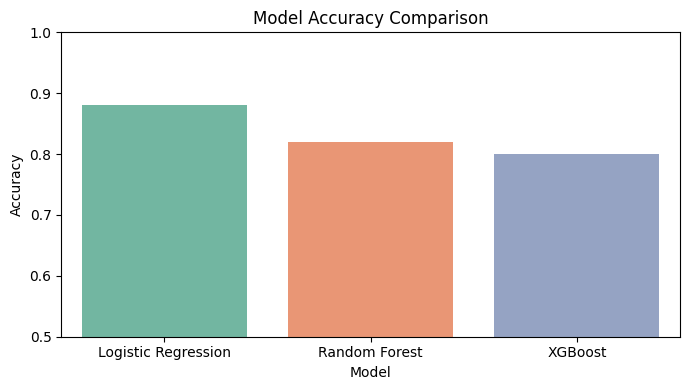

In [47]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})
results['Accuracy'] = results['Accuracy'].round(4)
print(results.to_string(index=False))

# Bar chart
plt.figure(figsize=(7, 4))
sns.barplot(x='Model', y='Accuracy', data=results, palette='Set2')
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()


### 1.5 Confusion Matrix — Best Model (Random Forest)

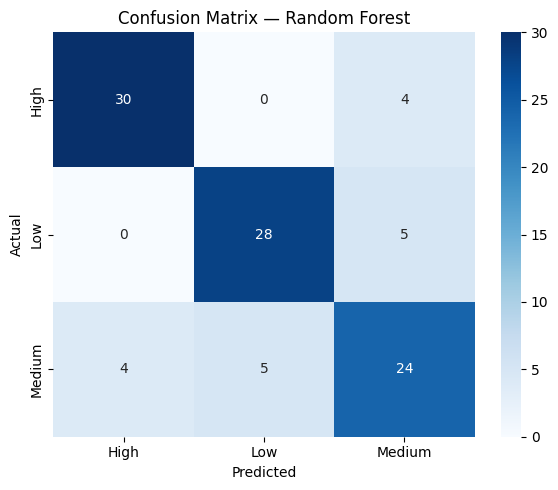

In [48]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()


## #Cross-Validation

In [49]:
cv_lr  = cross_val_score(lr_pipeline,  X, y_encoded, cv=5, scoring='accuracy')
cv_rf  = cross_val_score(rf_pipeline,  X, y_encoded, cv=5, scoring='accuracy')
cv_xgb = cross_val_score(xgb_pipeline, X, y_encoded, cv=5, scoring='accuracy')

print(f"Logistic Regression CV Accuracy : {cv_lr.mean():.4f}")
print(f"Random Forest CV Accuracy       : {cv_rf.mean():.4f}")
print(f"XGBoost CV Accuracy             : {cv_xgb.mean():.4f}")


Logistic Regression CV Accuracy : 0.8460
Random Forest CV Accuracy       : 0.7540
XGBoost CV Accuracy             : 0.7820


## #A/B Testing

In [50]:
from scipy import stats
from sklearn.model_selection import StratifiedKFold

In [52]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_lr  = cross_val_score(lr_pipeline,X, y_encoded,cv=cv,scoring='accuracy')
scores_rf  = cross_val_score(rf_pipeline,X, y_encoded,cv=cv,scoring='accuracy')
scores_xgb = cross_val_score(xgb_pipeline,X, y_encoded,cv=cv,scoring='accuracy')

print("LR  fold scores:", scores_lr.round(4))
print("RF  fold scores:", scores_rf.round(4))
print("XGB fold scores:", scores_xgb.round(4))

LR  fold scores: [0.9  0.84 0.86 0.8  0.86 0.84 0.84 0.78 0.8  0.92]
RF  fold scores: [0.82 0.76 0.86 0.76 0.76 0.72 0.7  0.7  0.76 0.86]
XGB fold scores: [0.86 0.74 0.86 0.82 0.78 0.74 0.82 0.72 0.76 0.88]


In [53]:
ab_summary = pd.DataFrame({
    'Model'        : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Mean Accuracy': [scores_lr.mean(), scores_rf.mean(), scores_xgb.mean()],
    'Std Dev'      : [scores_lr.std(),  scores_rf.std(),  scores_xgb.std()]
}).round(4)

print(ab_summary.to_string(index=False))

              Model  Mean Accuracy  Std Dev
Logistic Regression          0.844   0.0418
      Random Forest          0.770   0.0560
            XGBoost          0.798   0.0547


In [54]:
alpha = 0.05

pairs = [
    ('Logistic Regression', 'Random Forest', scores_lr, scores_rf),
    ('Logistic Regression', 'XGBoost',       scores_lr, scores_xgb),
    ('Random Forest',       'XGBoost',        scores_rf, scores_xgb),
]

print(f"Alpha (significance level): {alpha}\n")
print(f"{'Comparison':<40} {'t-stat':>8} {'p-value':>10} {'Verdict':>25}")
print("-" * 88)

for (m1, m2, s1, s2) in pairs:
    t_stat, p_val = stats.ttest_rel(s1, s2)
    verdict = "Reject H0 — real difference" if p_val < alpha else "Fail to reject H0 — could be chance"
    print(f"{m1} vs {m2:<25} {t_stat:>8.4f} {p_val:>10.4f}  {verdict}")

Alpha (significance level): 0.05

Comparison                                 t-stat    p-value                   Verdict
----------------------------------------------------------------------------------------
Logistic Regression vs Random Forest               5.6867     0.0003  Reject H0 — real difference
Logistic Regression vs XGBoost                     3.6316     0.0055  Reject H0 — real difference
Random Forest vs XGBoost                    -2.2645     0.0498  Reject H0 — real difference


## #Explainable AI with SHAP

SHAP tells us **why** the model made each prediction.
It shows which features push a prediction toward High vs Low priority.


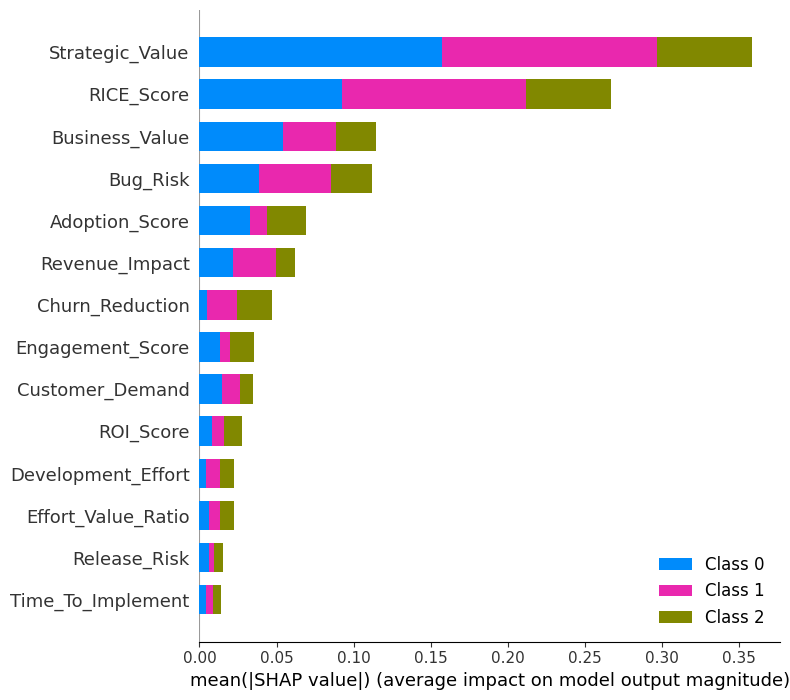

In [55]:
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

rf_model  = rf_pipeline.named_steps['model']
explainer = shap.TreeExplainer(rf_model)
shap_vals = explainer.shap_values(X_test_t)

# Summary plot — overall feature importance
shap.summary_plot(shap_vals, X_test_t, feature_names=X.columns, plot_type='bar')


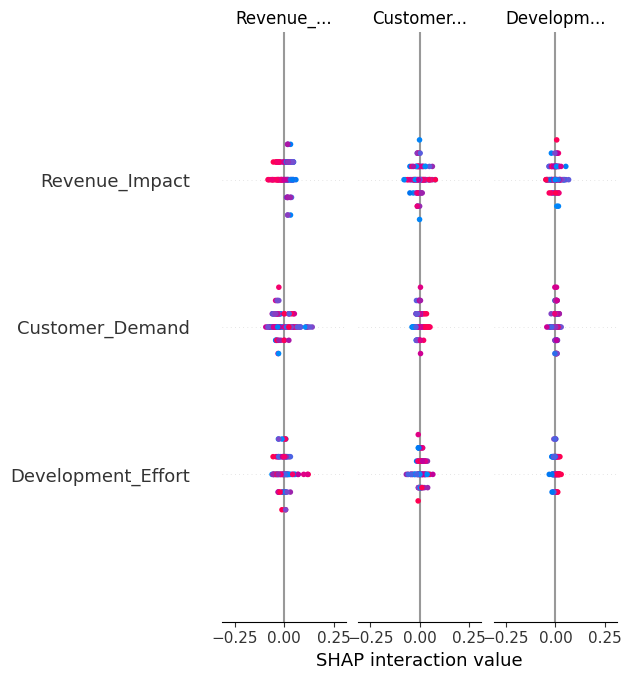

In [56]:
# Detailed beeswarm — direction of impact per feature
shap.summary_plot(shap_vals, X_test_t, feature_names=X.columns)


## #Export Dataset for Power BI

In [ ]:
# Add ML predictions back into the dataframe for Power BI
data['ML_Priority_Predicted'] = encoder.inverse_transform(
    rf_pipeline.predict(X)
)

data.to_csv('AI_product_final.csv', index=False)
print("Exported AI_product_final.csv")
print("Shape:", data.shape)
data.head()
